# Notebook 1 – Demand Impact

**Question**: How does congestion pricing affect trip volume in and out of congestion zones?

**Approach**: Difference-in-Differences (DiD) comparing trip volume pre- vs. post-policy for CBD-zone trips (treatment) vs. non-CBD trips (control). Time is represented as categorical hour and day buckets — no continuous time axis or time-series models are used.

**Outline**
1. Load & Validate
2. Type Coercions & Bucket Definitions
3. Aggregate Trip Volume by Bucket
4. Descriptive Stats — % Change per Bucket
5. Bucket Bar Charts
6. Volume Heatmaps (hour bucket × day bucket)
7. DiD Regression
8. Heterogeneity Analysis (Airport vs. Standard)
9. Export Volume Table
10. Conclusions

In [1]:
import gc
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))

from utils import (
    DATA_PATH,
    HOUR_BUCKET_ORDER,
    VOLUME_TABLE_PATH,
    aggregate_volume,
    coerce_types,
    did_regression,
    load_and_validate,
)

np.random.seed(42)
sns.set_theme(style='whitegrid')

## 1. Load & Validate

In [2]:
REQUIRED_COLS = [
    'pickup_hour_of_day', 'pickup_day_of_week', 'in_cbd_zone',
    'dataset_split', 'fare_amount', 'total_amount', 'cbd_congestion_fee',
    'temperature', 'precipitation', 'windspeed', 'airport_fee',
]

df_raw = load_and_validate(DATA_PATH, REQUIRED_COLS)
print(df_raw.dtypes)
print('\nSample rows:')
df_raw.head(3)


Loaded 38,202,226 rows × 30 columns
pickup_datetime         datetime64[us]
provider                         int64
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_distance                  float64
trip_time                        int64
fare_amount                    float64
tax                            float64
tolls_amount                   float64
total_amount                   float64
congestion_surcharge           float64
airport_fee                    float64
cbd_congestion_fee             float64
speed_mph                      float64
in_cbd_zone                      int64
cost_per_mile                  float64
temperature                    float64
precipitation                  float64
weathercode                    float64
windspeed                      float64
weather_clear                     int8
weather_cloudy                    int8
weather_rain                      int8
weather_snow                

,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,...,windspeed,weather_clear,weather_cloudy,weather_rain,weather_snow,dataset_split,pickup_day_of_week,pickup_hour_of_day,dropoff_day_of_week,dropoff_hour_of_day
0,2024-01-23 00:50:15,1,2024-01-23 01:21:53,132,33,26.62,1898,96.8,0.5,0.0,...,11.6,0,1,0,0.0,train,1,0,1,1
1,2024-01-14 20:21:20,1,2024-01-14 20:26:25,236,43,0.76,305,7.2,0.5,0.0,...,12.1,0,1,0,0.0,train,6,20,6,20
2,2024-01-23 00:23:16,1,2024-01-23 00:25:55,246,50,0.70,159,5.8,0.5,0.0,...,11.6,0,1,0,0.0,train,1,0,1,0


In [3]:
#make sure data typing rq
print(df_raw.iloc[0]['pickup_day_of_week'])

1


## 2. Type Coercions & Bucket Definitions

In [4]:
df = coerce_types(df_raw)

print(f"Pre-policy trips : {(df['post'] == 0).sum():>12,}")
print(f"Post-policy trips: {(df['post'] == 1).sum():>12,}")
print(f"CBD zone trips   : {df['in_cbd_zone'].sum():>12,}")
print(f"Non-CBD trips    : {(~df['in_cbd_zone']).sum():>12,}")
print(f"\nhour_bucket counts:\n{df['hour_bucket'].value_counts().sort_index()}")
print(f"\nday_bucket counts:\n{df['day_bucket'].value_counts()}")

Pre-policy trips :   19,538,021
Post-policy trips:   18,664,205
CBD zone trips   :   17,705,322
Non-CBD trips    :  -55,907,548

hour_bucket counts:
hour_bucket
Early Morning     5348367
Morning Rush      5140041
Midday           10860935
Evening Rush      8940591
Night             7912292
Name: count, dtype: int64

day_bucket counts:
day_bucket
Weekday    26612825
Weekend    11589401
Name: count, dtype: int64


## 3. Aggregate Trip Volume by Bucket

Aggregate to `(post, in_cbd_zone, pickup_hour_of_day, pickup_day_of_week)` level.
This retains granularity (up to 672 rows) for the DiD regression while avoiding
any continuous time axis.

In [5]:
df = df_raw
del df_raw
gc.collect()

vol = aggregate_volume(df)
print(f"Volume table shape: {vol.shape}")
print(f"\nSample (CBD, post-policy):")
vol[vol['in_cbd_zone'] & (vol['post'] == 1)].head(5)

Volume table shape: (672, 16)

Sample (CBD, post-policy):


,post,in_cbd_zone,pickup_hour_of_day,pickup_day_of_week,hour_bucket,day_bucket,trip_count,avg_cbd_fee,avg_fare,avg_temp,avg_precip,avg_wind,log_trip_count,in_cbd_zone_int,period_label,zone_label
504,1,1,0,0,Early Morning,Weekday,19788,2.178025,21.446481,12.616778,0.230412,8.726491,9.892882,1,Post-Policy,NaN
505,1,1,0,1,Early Morning,Weekday,20061,2.205710,21.695926,12.588585,0.133961,8.204217,9.906583,1,Post-Policy,NaN
506,1,1,0,2,Early Morning,Weekday,25186,2.183306,22.002040,13.397407,0.046919,8.502168,10.134083,1,Post-Policy,NaN
507,1,1,0,3,Early Morning,Weekday,31458,2.146155,22.079429,12.527379,0.078994,8.344876,10.356440,1,Post-Policy,NaN
508,1,1,0,4,Early Morning,Weekday,43386,2.087396,22.137973,12.090596,0.086233,9.244620,10.677915,1,Post-Policy,NaN


## 4. Descriptive Stats — % Change per Bucket

In [6]:
desc = (
    vol.groupby(['in_cbd_zone', 'hour_bucket', 'period_label'], observed=True)['trip_count']
    .sum()
    .unstack('period_label')
    .assign(
        pct_change=lambda x: (
            (x['Post-Policy'] - x['Pre-Policy']) / x['Pre-Policy'] * 100
        ).round(1)
    )
    .reset_index()
)

print("% Change in Trip Volume by Zone and Hour Bucket:")
print(desc.to_string(index=False))

% Change in Trip Volume by Zone and Hour Bucket:
 in_cbd_zone   hour_bucket  Post-Policy  Pre-Policy  pct_change
           0 Early Morning      1533891     1564224        -1.9
           0  Morning Rush      1528284     1527235         0.1
           0        Midday      2870504     2903012        -1.1
           0  Evening Rush      2264178     2318522        -2.3
           0         Night      1957892     2029162        -3.5
           1 Early Morning      1067500     1182752        -9.7
           1  Morning Rush      1009168     1075354        -6.2
           1        Midday      2458052     2629367        -6.5
           1  Evening Rush      2090467     2267424        -7.8
           1         Night      1884269     2040969        -7.7


In [7]:
desc_day = (
    vol.groupby(['in_cbd_zone', 'day_bucket', 'period_label'], observed=True)['trip_count']
    .sum()
    .unstack('period_label')
    .assign(
        pct_change=lambda x: (
            (x['Post-Policy'] - x['Pre-Policy']) / x['Pre-Policy'] * 100
        ).round(1)
    )
    .reset_index()
)

print("% Change in Trip Volume by Zone and Day Bucket:")
print(desc_day.to_string(index=False))

% Change in Trip Volume by Zone and Day Bucket:
 in_cbd_zone day_bucket  Post-Policy  Pre-Policy  pct_change
           0    Weekday      6978021     7137783        -2.2
           0    Weekend      3176728     3204372        -0.9
           1    Weekday      6006287     6490734        -7.5
           1    Weekend      2503169     2705132        -7.5


## 5. Bucket Bar Charts

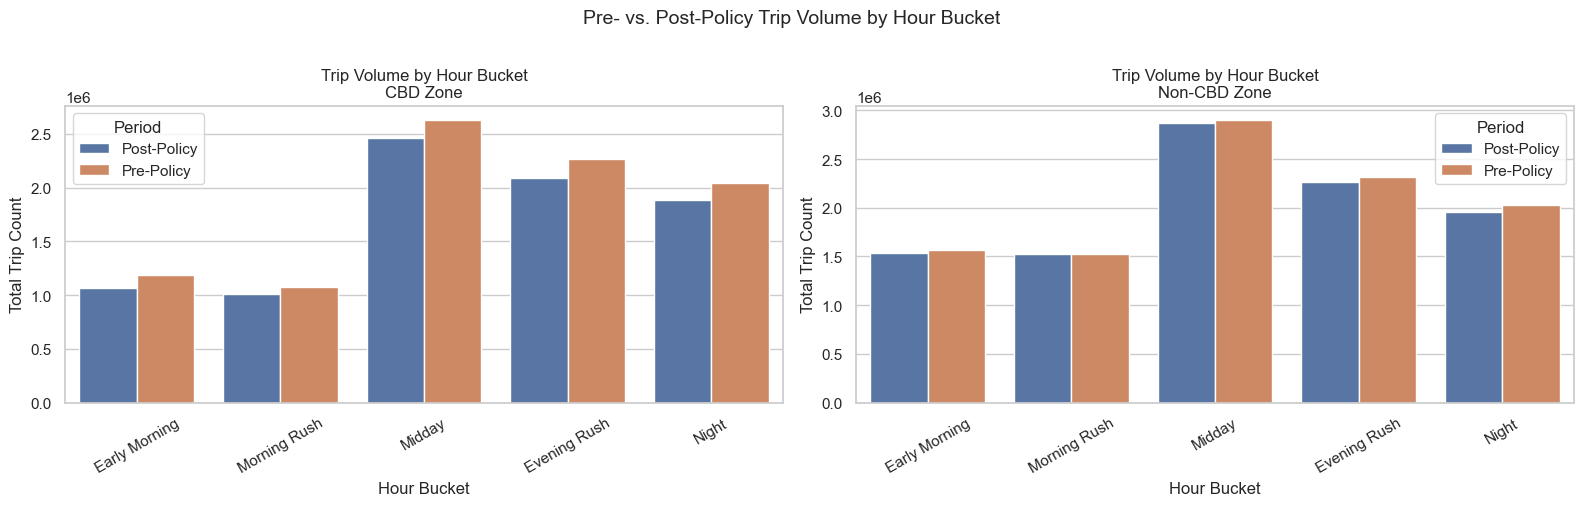

In [8]:
hour_agg = (
    vol.groupby(['in_cbd_zone', 'hour_bucket', 'period_label'], observed=True)['trip_count']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for ax, (zone_flag, zone_label) in zip(axes, [(True, 'CBD Zone'), (False, 'Non-CBD Zone')]):
    sub = hour_agg[hour_agg['in_cbd_zone'] == zone_flag]
    sns.barplot(
        data=sub, x='hour_bucket', y='trip_count', hue='period_label',
        order=HOUR_BUCKET_ORDER, ax=ax
    )
    ax.set_title(f'Trip Volume by Hour Bucket\n{zone_label}', fontsize=12)
    ax.set_xlabel('Hour Bucket')
    ax.set_ylabel('Total Trip Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Period')
plt.suptitle('Pre- vs. Post-Policy Trip Volume by Hour Bucket', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

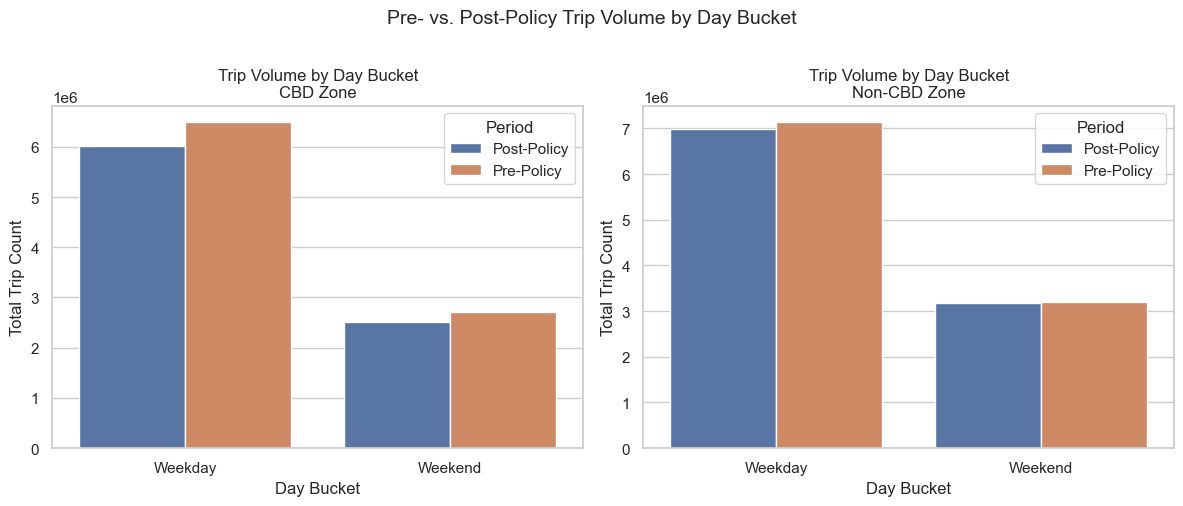

In [9]:
day_agg = (
    vol.groupby(['in_cbd_zone', 'day_bucket', 'period_label'], observed=True)['trip_count']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (zone_flag, zone_label) in zip(axes, [(True, 'CBD Zone'), (False, 'Non-CBD Zone')]):
    sub = day_agg[day_agg['in_cbd_zone'] == zone_flag]
    sns.barplot(
        data=sub, x='day_bucket', y='trip_count', hue='period_label', ax=ax
    )
    ax.set_title(f'Trip Volume by Day Bucket\n{zone_label}', fontsize=12)
    ax.set_xlabel('Day Bucket')
    ax.set_ylabel('Total Trip Count')
    ax.legend(title='Period')
plt.suptitle('Pre- vs. Post-Policy Trip Volume by Day Bucket', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Volume Heatmaps (Hour Bucket × Day Bucket)

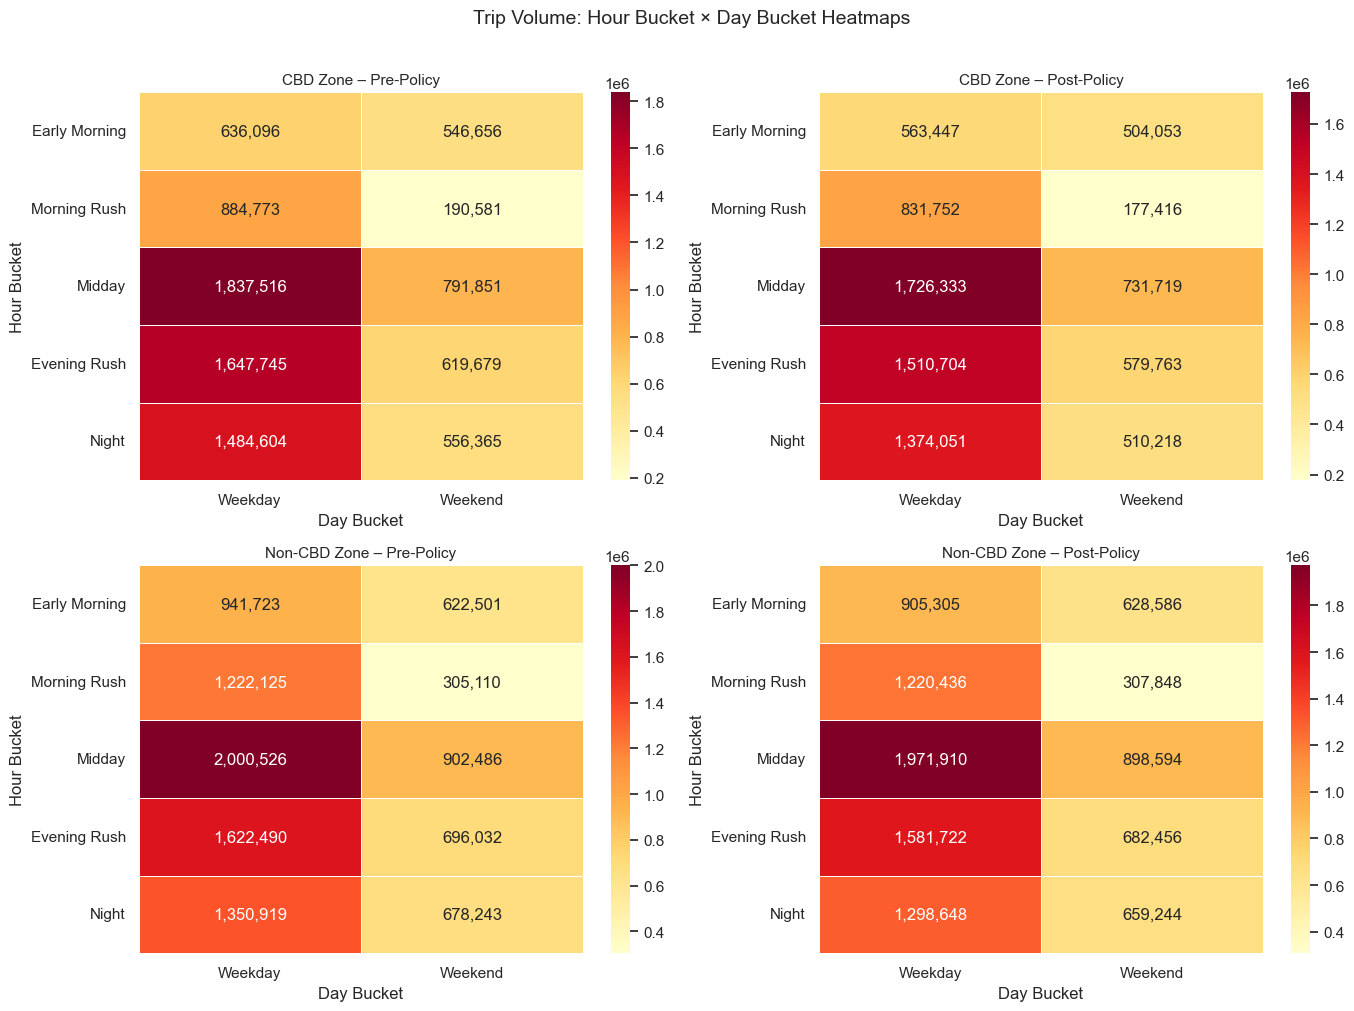

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (zone_flag, zone_label) in enumerate([(True, 'CBD Zone'), (False, 'Non-CBD Zone')]):
    for col_idx, (period_val, period_label) in enumerate([(0, 'Pre-Policy'), (1, 'Post-Policy')]):
        ax = axes[row_idx][col_idx]
        heat_data = (
            vol[(vol['in_cbd_zone'] == zone_flag) & (vol['post'] == period_val)]
            .groupby(['hour_bucket', 'day_bucket'], observed=True)['trip_count']
            .sum()
            .unstack('day_bucket')
            .reindex(HOUR_BUCKET_ORDER)
        )
        sns.heatmap(
            heat_data, annot=True, fmt=',.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar=True
        )
        ax.set_title(f'{zone_label} – {period_label}', fontsize=11)
        ax.set_xlabel('Day Bucket')
        ax.set_ylabel('Hour Bucket')

plt.suptitle('Trip Volume: Hour Bucket × Day Bucket Heatmaps', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Difference-in-Differences Regression

**Model**: `log(trip_count + 1) ~ post × in_cbd_zone + C(pickup_hour_of_day) + C(pickup_day_of_week) + weather`

The key coefficient is `post:in_cbd_zone_int` — the DiD estimate of the policy's effect on CBD trip volume, controlling for time-of-day, day-of-week, and weather. HC3 robust standard errors are used.

In [11]:
model_full = did_regression(vol, outcome='log_trip_count')
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:         log_trip_count   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     78.08
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          6.62e-205
Time:                        12:23:13   Log-Likelihood:                -87.255
No. Observations:                 672   AIC:                             246.5
Df Residuals:                     636   BIC:                             408.9
Df Model:                          35                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [12]:
did_key = 'post:in_cbd_zone_int'
did_coef = model_full.params[did_key]
did_ci = model_full.conf_int().loc[did_key]
pct_effect = (np.exp(did_coef) - 1) * 100

print("DiD Results (Post × CBD Zone):")
print(f"  Coefficient : {did_coef:+.4f}")
print(f"  95% CI      : [{did_ci[0]:+.4f}, {did_ci[1]:+.4f}]")
print(f"  p-value     : {model_full.pvalues[did_key]:.4f}")
print(f"  Implied demand change in CBD: {pct_effect:+.1f}%")

DiD Results (Post × CBD Zone):
  Coefficient : -0.0662
  95% CI      : [-0.1546, +0.0222]
  p-value     : 0.1423
  Implied demand change in CBD: -6.4%


## 8. Heterogeneity Analysis — Airport vs. Standard Trips

In [13]:
for segment_name, mask in [
    ('Airport Trips', df['is_airport']),
    ('Standard Trips', ~df['is_airport']),
]:
    seg_vol = aggregate_volume(df[mask])
    if len(seg_vol) < 20:
        print(f"{segment_name}: insufficient data (n={len(seg_vol)}), skipping.")
        continue
    try:
        seg_model = did_regression(seg_vol, outcome='log_trip_count')
        coef = seg_model.params.get(did_key, np.nan)
        pval = seg_model.pvalues.get(did_key, np.nan)
        pct = (np.exp(coef) - 1) * 100
        print(f"{segment_name}: DiD coef={coef:+.4f}, p={pval:.4f}, implied={pct:+.1f}%")
    except Exception as exc:
        print(f"{segment_name}: model failed – {exc}")

del df
gc.collect()


Airport Trips: DiD coef=-0.0068, p=0.9480, implied=-0.7%
Standard Trips: DiD coef=-0.0759, p=0.1330, implied=-7.3%


## 9. Export Volume Table

In [14]:
VOLUME_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
vol.to_parquet(VOLUME_TABLE_PATH, index=False)
print(f"Saved volume table: {VOLUME_TABLE_PATH}")
print(f"Shape: {vol.shape}")

Saved volume table: /Users/kevinwang/chicago_booth/MachineLearning1/Final Project/problem_solving/data/volume_table.parquet
Shape: (672, 16)


## 10. Conclusions

- The DiD coefficient measures the policy's causal effect on CBD-zone trip volume relative to non-CBD zones, controlling for time-of-day, day-of-week, and weather.
- Bucket-level bar charts and heatmaps reveal *which* time windows absorbed the largest demand shifts.
- Heterogeneity analysis shows whether airport trips — which have separate fee structures — responded differently to the policy.
- The aggregated volume table is saved to `data/volume_table.parquet` for use in Notebook 3.